In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\bejja\Documents\ecommerce-sales-analytics\data\superstore_sales.csv", encoding="latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 9994
Number of Columns: 21

Column Names:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [5]:
print("Data Types:")
print(df.dtypes)

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [6]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [9]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
print(df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [10]:
df.drop(columns=["Row ID"], inplace=True)
print("Number of columns after cleaning:", df.shape[1])

Number of columns after cleaning: 20


In [11]:
print("Negative Sales:", (df["Sales"] < 0).sum())
print("Invalid Quantities:", (df["Quantity"] <= 0).sum())
print("Invalid Discounts:", ((df["Discount"] < 0) | (df["Discount"] > 1)).sum())

Negative Sales: 0
Invalid Quantities: 0
Invalid Discounts: 0


In [13]:
df.to_csv(r"C:\Users\bejja\Documents\ecommerce-sales-analytics\data\cleaned_superstore_sales.csv", index=False)

print("Cleaned dataset saved successfully!")
print("Final Dataset Shape:", df.shape)

Cleaned dataset saved successfully!
Final Dataset Shape: (9994, 20)


In [14]:
# Overall business performance
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))
print("Total Quantity Sold:", df["Quantity"].sum())
print("Total Orders:", df["Order ID"].nunique())
print("Total Customers:", df["Customer ID"].nunique())

Total Sales: 2297200.86
Total Profit: 286397.02
Total Quantity Sold: 37873
Total Orders: 5009
Total Customers: 793


In [15]:
category_analysis = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Quantity_Sold=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False)

category_analysis

,Total_Sales,Total_Profit,Quantity_Sold
Category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906


In [16]:
region_analysis = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).sort_values("Total_Sales", ascending=False)

region_analysis

,Total_Sales,Total_Profit
Region,,
West,725457.8245,108418.4489
East,678781.2400,91522.7800
Central,501239.8908,39706.3625
South,391721.9050,46749.4303


In [17]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month

monthly_sales = df.groupby(["Year", "Month"])["Sales"].sum().reset_index()

monthly_sales.head(10)

,Year,Month,Sales
0,2014,1,14236.8950
1,2014,2,4519.8920
2,2014,3,55691.0090
3,2014,4,28295.3450
4,2014,5,23648.2870
5,2014,6,34595.1276
6,2014,7,33946.3930
7,2014,8,27909.4685
8,2014,9,81777.3508
9,2014,10,31453.3930


In [18]:
numeric_cols = df[["Sales", "Quantity", "Discount", "Profit"]]

correlation = numeric_cols.corr()

correlation

,Sales,Quantity,Discount,Profit
Sales,1.000000,0.200795,-0.028190,0.479064
Quantity,0.200795,1.000000,0.008623,0.066253
Discount,-0.028190,0.008623,1.000000,-0.219487
Profit,0.479064,0.066253,-0.219487,1.000000


In [19]:
Q1 = df["Sales"].quantile(0.25)
Q3 = df["Sales"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

sales_outliers = df[
    (df["Sales"] < lower_bound) |
    (df["Sales"] > upper_bound)
]

print("Number of Sales Outliers:", len(sales_outliers))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))

Number of Sales Outliers: 1167
Lower Bound: -271.71
Upper Bound: 498.93


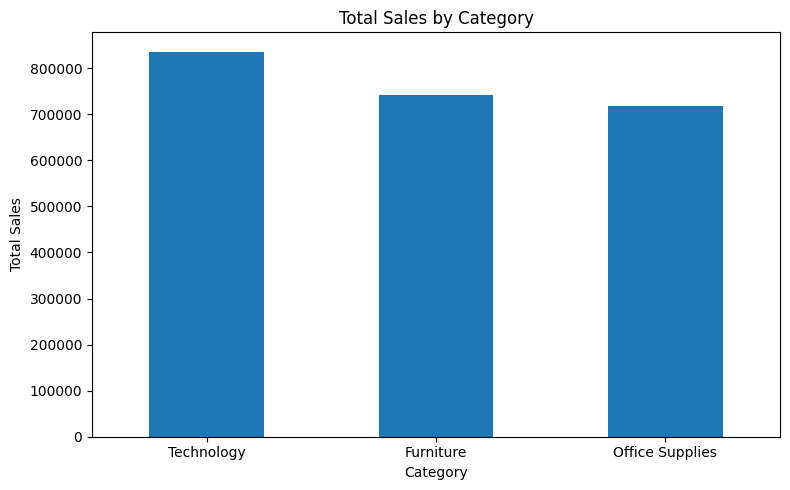

In [20]:
# Visualization 1: Sales by Category
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar")
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Finding
Technology generated the highest total sales among all product categories. 
Furniture ranked second in sales, followed by Office Supplies.

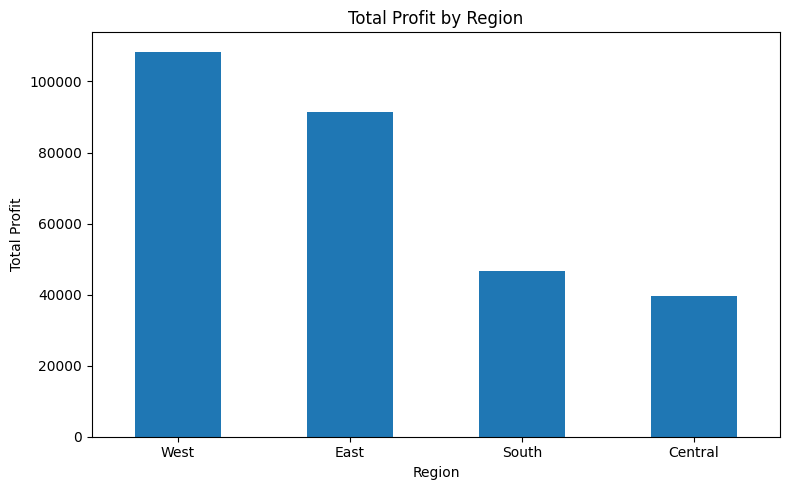

In [21]:
# Visualization 2: Profit by Region
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
plt.figure(figsize=(8, 5))
region_profit.plot(kind="bar")
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Finding
The West region generated the highest profit, followed by the East region.
Although the Central region had higher sales than the South region, its total
profit was lower, indicating weaker profitability.

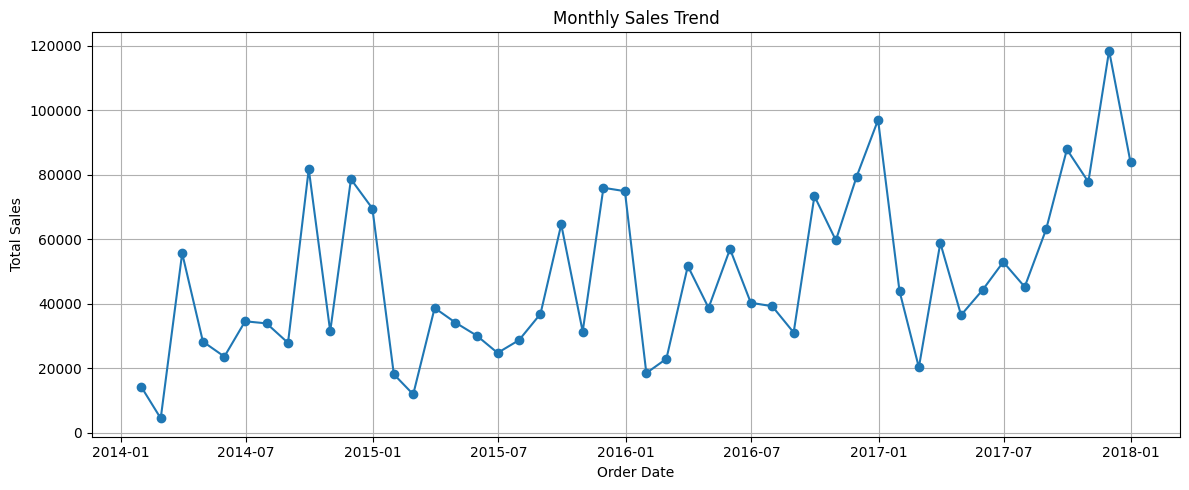

In [22]:
# Visualization 3: Monthly Sales Trend
monthly_trend = (
    df.set_index("Order Date")
      .resample("ME")["Sales"]
      .sum()
)
plt.figure(figsize=(12, 5))
plt.plot(monthly_trend.index, monthly_trend.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Order Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

### Finding
Monthly sales fluctuate over time, with noticeable peaks during certain
months. The trend indicates that sales performance varies seasonally,
suggesting periods of stronger customer demand.

In [23]:
highest_month = monthly_trend.idxmax()
highest_sales = monthly_trend.max()

print("Highest Sales Month:", highest_month.strftime("%B %Y"))
print("Highest Monthly Sales:", round(highest_sales, 2))

Highest Sales Month: November 2017
Highest Monthly Sales: 118447.82


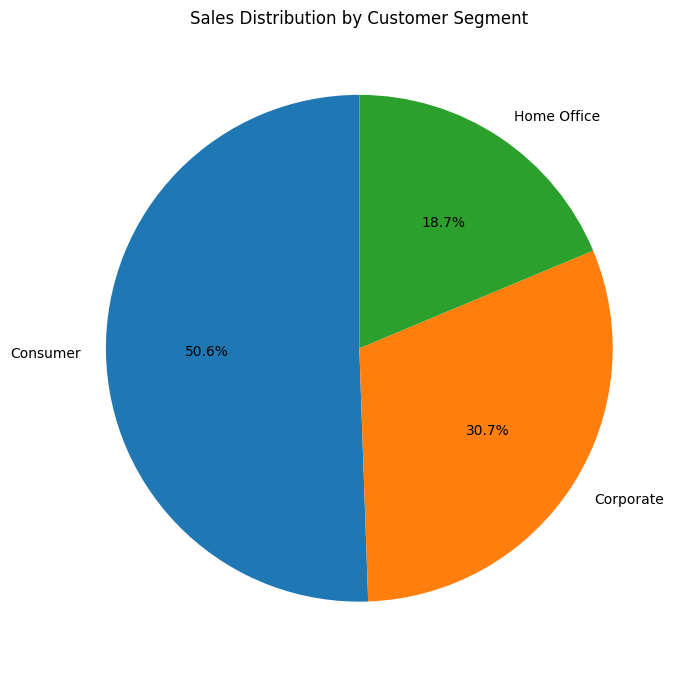

In [24]:
# Visualization 4: Sales by Customer Segment
segment_sales = df.groupby("Segment")["Sales"].sum()
plt.figure(figsize=(7, 7))
plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Sales Distribution by Customer Segment")
plt.tight_layout()
plt.show()

### Finding
The Consumer segment contributes the largest share of total sales,
making it the most important customer segment in terms of revenue.

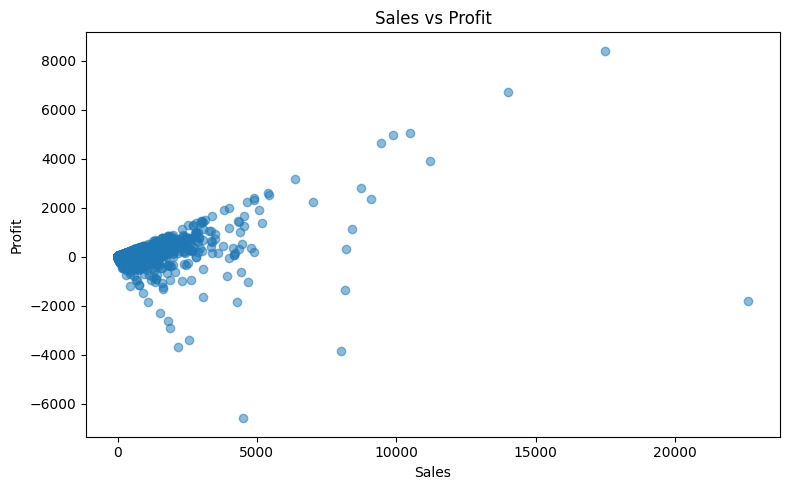

In [25]:
# Visualization 5: Sales vs Profit
plt.figure(figsize=(8, 5))
plt.scatter(df["Sales"], df["Profit"], alpha=0.5)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

### Finding
Sales and Profit show a moderate positive relationship.
Higher sales are generally associated with higher profit, but some
high-sales transactions still produce low or negative profit.

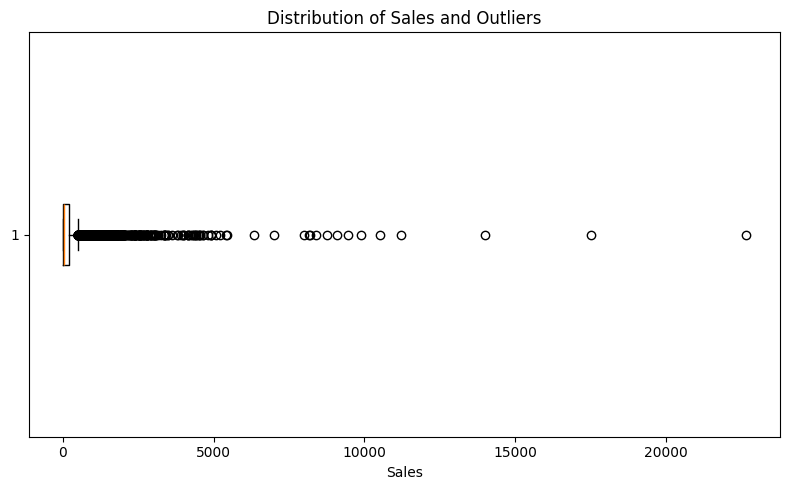

In [26]:
# Visualization 6: Sales Outliers
plt.figure(figsize=(8, 5))
plt.boxplot(df["Sales"], vert=False)
plt.title("Distribution of Sales and Outliers")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

### Finding
The Sales variable contains several high-value outliers.
These records were retained because they may represent genuine large
customer orders and can provide useful business information.

# Task 7: Business Insights & Recommendations
## Business Insights

1. **Technology is the strongest product category**
   - Technology generated approximately $836,154 in sales and $145,455 in profit, making it the highest-performing category in both sales and profitability.

2. **Furniture has weak profitability despite high sales**
   - Furniture generated approximately $742,000 in sales but only $18,451 in profit.
   - This indicates that high revenue in Furniture is not translating into strong profitability.

3. **West is the best-performing region**
   - The West region generated approximately $725,458 in sales and $108,418 in profit, making it the strongest region overall.

4. **South has the lowest sales**
   - The South region recorded approximately $391,722 in sales, the lowest among the four regions.
   - This indicates an opportunity to improve sales performance in the South.

5. **November 2017 recorded the highest monthly sales**
   - Monthly sales peaked at approximately $118,447.82 in November 2017, indicating particularly strong customer demand during this period.

6. **Higher discounts are associated with lower profit**
   - Discount and Profit have a negative correlation of approximately -0.219.
   - This suggests that excessive discounting may negatively affect profitability.

7. **Consumer is the largest customer segment**
   - The Consumer segment contributes the largest share of total sales, making it the company's most important customer segment.

## Business Recommendations

1. **Improve Furniture profitability**
   - Review pricing, discounts and costs for Furniture products because the category generates high sales but comparatively low profit.
   - Focus promotional efforts on profitable Furniture sub-categories and reduce unnecessary discounting on loss-making products.

2. **Strengthen sales in underperforming regions**
   - Increase targeted marketing and promotional campaigns in the South region while studying successful strategies used in the West.
   - Regional product preferences should be analyzed to develop more targeted sales strategies.

3. **Optimize the discount strategy**
   - Since discounts show a negative relationship with profit, the business should avoid excessive discounts and evaluate discount levels based on product profitability.

## Conclusion

The analysis shows that Technology and the West region are major contributors to business performance, while Furniture profitability and South-region sales require improvement. The company can improve overall profitability by optimizing discounts, focusing on profitable products and strengthening sales strategies in underperforming regions.